#### 常數

In [1]:
JSON_PATH = "./json/twist/close_60.json"

#### 套件

In [2]:
from src.json_to_pose.base import Pose, PoseAnalyzer
from src.json_to_pose.values import blazepose_lines
import src.utils.plot_painter as plot_painter
from src.utils.process_data import translate_multi_kpt_to_plot_pos
import matplotlib.pyplot as plt

# 參考類型
from matplotlib.axes import Axes
from mpl_toolkits.mplot3d import Axes3D

#### 變數

In [3]:
pose = Pose(JSON_PATH)
analyzer = PoseAnalyzer(pose)
angles = analyzer.get_all_pose_shoulder_hip_staggered_angle(True)

In [4]:
max_angle = max(angles)
idx_max = angles.index(max(angles))
idx_min = angles.index(min(angles))

##### 圖表變數

In [5]:
### 圖表標題
analyze_angle_title = (
    "close_60\n"
    + f"max angles: {max_angle:.2f}\n"
    + f"max angle index: {idx_max}\n"
    + f"min angle index: {idx_min}"
)
min_pose_title = "min staggered angle pose"
max_pose_title = "max staggered angle pose"

In [6]:
### 設定圖表資訊

# 資料範圍
data_range_x = [-1, 1]  # x 軸
data_range_y = [-1, 1]  # y 軸
data_range_z = [0, 2]  # z 軸

# 線條顏色
c_left = "#f00"  # 左邊
c_center = "#0f0"  # 中間
c_right = "#00f"  # 右邊
c_kpts = "#000"  # 關鍵點

dot_size = 5  # 繪製點的大小
elev, azim, roll = 0, 270, 0  # 視角設定

In [7]:
### 設定輸出資訊
is_3d = True  # 是否為 3D 圖表和 3D 姿勢
line_lst = blazepose_lines  # 設定連線列表

In [8]:
### 最小肩臀角度姿勢變數
kpt_min = pose.get_pose_kpt_positions(idx_min, 0, is_3d)
left_min, center_min, right_min = analyzer.get_pose_line_postions(
    idx_min, 0, blazepose_lines, is_3d
)
kpt_min, left_min, center_min, right_min = translate_multi_kpt_to_plot_pos(
    kpt_min, kpt_min, left_min, center_min, right_min
)

### 最大肩臀角度姿勢變數
kpt_max = pose.get_pose_kpt_positions(idx_max, 0, is_3d)
left_max, center_max, right_max = analyzer.get_pose_line_postions(
    idx_max, 0, blazepose_lines, is_3d
)
kpt_max, left_max, center_max, right_max = translate_multi_kpt_to_plot_pos(
    kpt_max, kpt_max, left_max, center_max, right_max
)

#### 建立肩臀角度分析圖表

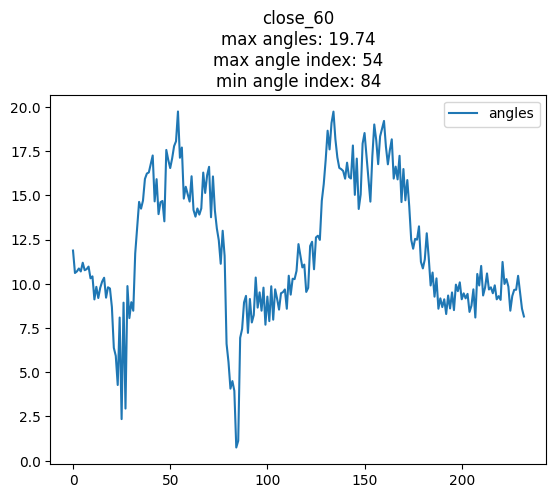

In [9]:
fig = plt.figure()

ax = fig.add_subplot()
ax.set_title(analyze_angle_title)
ax.plot(range(len(angles)), angles, label="angles")
ax.legend()

plt.show()

#### 顯示最小和最大肩臀角度所對應的身體姿勢

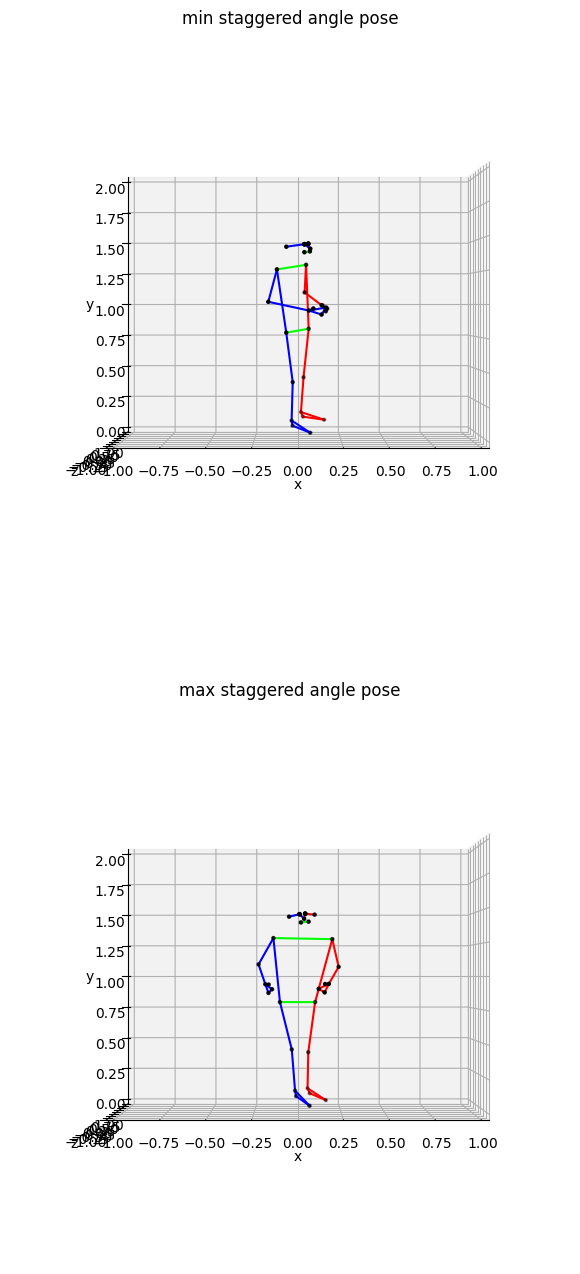

In [10]:
#### 設定圖表
fig = plt.figure(figsize=(8, 16))

#### 顯示最小和最大肩臀角度所對應的身體姿勢
if not is_3d:
    ax_min: Axes = fig.add_subplot(211)
    ax_max: Axes = fig.add_subplot(212)
    plot_painter.set_data_range(data_range_x, data_range_y, None, ax_min)
    plot_painter.set_data_range(data_range_x, data_range_y, None, ax_max)
else:
    ax_min: Axes3D = fig.add_subplot(211, projection="3d")
    ax_max: Axes3D = fig.add_subplot(212, projection="3d")
    ax_min.view_init(elev, azim, roll)
    ax_max.view_init(elev, azim, roll)
    plot_painter.set_data_range(data_range_x, data_range_y, data_range_z, ax_min)
    plot_painter.set_data_range(data_range_x, data_range_y, data_range_z, ax_max)

### 繪製圖表
ax_min.set_title(min_pose_title)
ax_max.set_title(max_pose_title)
# 繪製最小肩臀角度姿勢
plot_painter.draw_dots(kpt_min, is_3d, dot_size, c_kpts, "kpt", ax_min)
plot_painter.draw_lines(left_min, is_3d, c_left, ax_min)
plot_painter.draw_lines(center_min, is_3d, c_center, ax_min)
plot_painter.draw_lines(right_min, is_3d, c_right, ax_min)
# 繪製最大肩臀角度姿勢
plot_painter.draw_dots(kpt_max, is_3d, dot_size, c_kpts, "kpt", ax_max)
plot_painter.draw_lines(left_max, is_3d, c_left, ax_max)
plot_painter.draw_lines(center_max, is_3d, c_center, ax_max)
plot_painter.draw_lines(right_max, is_3d, c_right, ax_max)

plt.show()